# Computer Vision
## Exercise Sheet 5: Correlation-based Stereo Vision
### Erhardt Barth / Christoph Linse / Manuel Laufer / Kathleen Anderson
Universität zu Lübeck, Institut für Neuro- und Bioinformatik

In case of questions, contact us via email: *{erhardt.barth, c.linse, m.laufer, k.anderson} @uni-luebeck.de*

## Note: Please insert the names of all participating students:

1.
2.
3.
4.
5.


In [2]:
import sys, os
if 'google.colab' in sys.modules:
  if os.getcwd() == '/content':
    !git clone 'https://github.com/inb-luebeck/cs4250.git'
    os.chdir('cs4250')

Cloning into 'cs4250'...
remote: Enumerating objects: 94, done.
remote: Counting objects: 100% (94/94), done.
remote: Compressing objects: 100% (69/69), done.
remote: Total 94 (delta 41), reused 68 (delta 21), pack-reused 0 (from 0)
Receiving objects: 100% (94/94), 1.26 MiB | 6.22 MiB/s, done.
Resolving deltas: 100% (41/41), done.


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

#### Cross-correlation and Autocorrelation
*Cross correlation* is a standard way to estimate the degree of similarity (correlation) between two signals. For a discrete series it is defined as
$$\rho(dt)=\frac{\sum_{i}{[(x_i-\mu_{x})(y_{i+dt}-\mu_{y})]}}{\sqrt{\sum_{i}{(x_i-\mu_{x})^2}}\sqrt{\sum_{i}{(y_{i+dt}-\mu_{y})^2}}}$$
where $\rho$ denotes the *correlation coefficient*; $dt$ is the time shift, and $\mu_{x}$ and $\mu_{y}$ are the means of the two signals $x$ and $y$. The denominator normalizes the correlation coefficient such that $\rho \in [-1,1]$, the bounds indicate maximum correlation and $0$ means no correlation at all. The sums are only evaluated for indices where both $x_i$ and $y_{i+dt}$ exist.

When the correlation of a signal is computed against a temporally shifted version of itself, we call it *autocorrelation*, and define it as
$$\rho(dt)=\frac{\sum_{i}{[(x_i-\mu_{x})(x_{i+dt}-\mu_{x})]}}{(x_i-\mu_{x})^2}.$$

Cross-correlation can be used to determine the delay between two signals. In order to do this, we shift the second signal across a range of time shifts $[-dt, dt]$ and cross-correlate it with the first signal. The point of maximum correlation corresponds to the signal delay.

Write a Python function to calculate the cross-correlation between two signals for the range of delays $[-dt,dt]$.

The `ultrasound.npy` data file from the archive contains two ultrasound signals. Plot the two signals in one plot. Using the above algorithm, cross-correlate them to find the signal delay (using a maximum time shift of 100). Plot the values of the correlation coefficient for the given delay range.

In [4]:
def cross_corr_seq(X, Y, dt):
    # returns the cross-correlation sequence over
    # the time shift range [-dt,dt]

    rho_seq=[]
    for t in np.arange(-dt, dt):
        rho = cross_corr(X, Y, t)
        rho_seq.append(rho)

    return np.array(rho_seq)

def cross_corr(X, Y, dt):
    # Compute the correlation coeff. for time shift dt
    if dt >= 0:
        x_slice = X[:len(X)-dt]
        y_slice = Y[dt:]
    else: # dt is negative
        x_slice = X[-dt:]
        y_slice = Y[:len(Y)+dt]

    if len(x_slice) == 0:
        return 0.0

    mu_x = np.mean(x_slice)
    mu_y = np.mean(y_slice)

    numerator = np.sum((x_slice - mu_x) * (y_slice - mu_y))
    denom_x = np.sqrt(np.sum((x_slice - mu_x)**2))
    denom_y = np.sqrt(np.sum((y_slice - mu_y)**2))
    denominator = denom_x * denom_y

    if denominator == 0:
        return 0.0

    return numerator / denominator

The signal lag is 70.


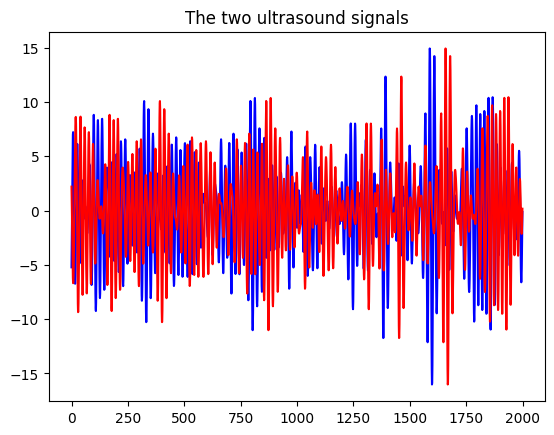

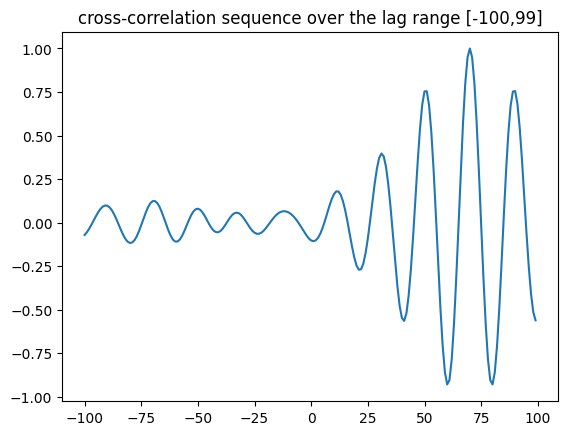

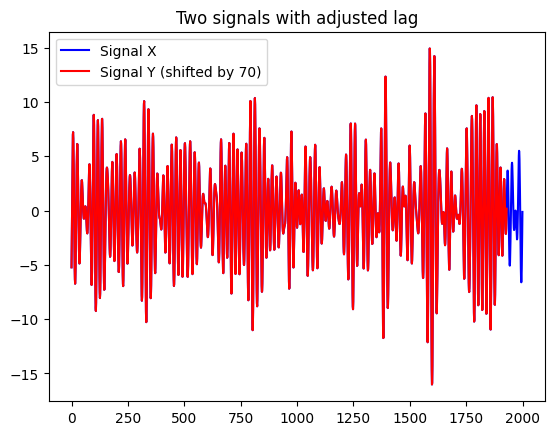

In [5]:
X =np.load('data/exercise_5/ultrasound.npy', allow_pickle=True)
Y = X.tolist()['Y'][0]
X = X.tolist()['X'][0]

_, ax = plt.subplots(1)
plt.plot(X, '-b')
plt.plot(Y, '-r')
ax.set_title('The two ultrasound signals')

# Compute cross correlation with dt=100
dt=100
rho_seq=cross_corr_seq(X, Y, dt)
max_idx = np.argmax(rho_seq)
max_rho = rho_seq.max()

# Compute lag value from the index of the max correlation
delay_range = np.arange(-dt,dt)
lag = delay_range[max_idx]
print('The signal lag is {}.'.format(lag))

# This plot should now work correctly
_, ax = plt.subplots(1)
ax.plot(delay_range, rho_seq)
ax.set_title(
    'cross-correlation sequence over the lag range [{},{}]'.format(
    -dt, dt-1) # Corrected the range display
)

# Plot the aligned signals
_, ax = plt.subplots(1)
plt.plot(X, '-b', label='Signal X')
# Adjust slicing based on the sign of the lag
if lag >= 0:
    plt.plot(Y[lag:], '-r', label=f'Signal Y (shifted by {lag})')
else:
    plt.plot(Y[:lag], '-r', label=f'Signal Y (shifted by {lag})')
ax.set_title('Two signals with adjusted lag')
ax.legend()
plt.show()

#### Correlation-based stereo algorithms

In this exercise, we will deal with the first problem of stereo vision:  the *correspondence problem*. For each image point in the left image, we want to find the corresponding point in the right image which is the projection of the same 3D-point.

**Keep in mind**: x denotes the horizontal axis of an image, in a numpy matrix this is the second axis (column x). Accordingly, y is the vertical axis in an image, which is the first axis in a numpy matrix (row y).

Our basic assumption is that corresponding image regions are similar, i.e. correlated. For each image pixel in the left image we are searching for its best match in the right image (or vice versa). Matching only single pixels results in too many false positives, so we choose a neighborhood window around the pixel and correlate it with all candidate blocks in the right image to find its best match (*block matching*). We assume rectified images, i.e. the epipolar lines are aligned, so we only need to search along the horizontal direction.


Possible similarity measures for block matching:

* Sum of Squared Differences (SSD): $$D(x,y,dx,dy)=\sum_{(i,j)\in W_{x,y}}{[I_l(i,j)-I_r(i-dx, j-dy)]^2}$$
* Normalized Cross-correlation (NCC): $$D(x,y,dx,dy)=\frac{\sum_{(i,j) \in W_{x,y}}{I_l(i,j) I_r(i-dx, j-dy)} } {\sqrt{\sum_{(i,j)\in W_{x,y}}{I_{l}^{2} (i,j)} \sum_{(i,j)\in W_{x,y}}{I_{r}^{2}{(i-dx, j-dy)} } } }$$

where $W_{x,y}$ is the square window of a certain size centered around pixel $(x,y)$, $I_l$ and $I_r$ are the left and right intensity images, and $(dx, dy)$ are the horizontal and vertical *disparities* (shifted amounts). Note that $dx$ is zero as we are only searching for horizontal shifts.

The goal is to find for each pixel $(x,y)$ the disparity $(0,dy)$ that either minimizes the error (sum of squared differences) or maximizes the similarity (cross-correlation).
In order to do this, we need to search over a range of disparities up to an allowed maximum disparity.
The output is the so-called `disparity map`: a map where pixel intensities describe the relative depth of points within a scene.

Implement functions `stereo_corr_...(left, right, win_size, max_disp)` which returns the disparity map `disp_map` for the stereo image pair `left` and `right`, given a correlation window size `win_size` and an upper limit on the allowed disparity range `max_disp`. Implement both the SSD and NCC-based block matching and match from left to right (i.e., for each window in the left image, search in the right image, so that the disparity map is with respect to the left image).

Note: When coded as nested `for` loops in python, this can be very slow. Be creative about how you code this. Using **convolution** (e.g. `cv2.blur`) is one possibility.

Use the stereo image pair `left.jpg` and `right.jpg` in the archive to test your algorithm. You may assume that the images are rectified. Visualize the resulting disparity map with the `plt.imshow` command.

Experiment with the following and explain the effects:

* try out different window sizes (e.g. `win_size` 3, 5, 9, 11),
* try out different values of maximum disparity (e.g. 10, 16),
* compare the results obtained with SSD and NCC.

**Task**: Find an example where NCC clearly outperforms SDD.

In [6]:
def stereo_corr_ssd(left, right, win_size, max_disp):
    """Computes the disparity map using Sum of Squared Differences."""

    if left.shape != right.shape:
        raise ValueError("Input images must have the same shape.")

    height, width = left.shape
    # Convert images to float32 for calculations
    left = left.astype(np.float32)
    right = right.astype(np.float32)

    # Initialize disparity map and a volume to store the minimum SSD costs
    disparity_map = np.zeros((height, width), dtype=np.uint8)
    min_ssd = np.full((height, width), np.inf, dtype=np.float32)

    # Iterate through all possible disparities from 0 to max_disp
    for d in range(max_disp):
        # Create a shifted version of the right image using np.roll
        right_shifted = np.roll(right, d, axis=1)
        # Set the wrapped-around pixels (on the left) to zero
        if d > 0:
            right_shifted[:, :d] = 0

        # Calculate the SSD for the current disparity
        diff = left - right_shifted
        ssd = diff**2

        # Sum the SSDs within the window using a fast box filter
        cost = cv2.blur(ssd, (win_size, win_size))

        # Create a mask to find where the current cost is better (lower)
        update_mask = cost < min_ssd
        # Update the minimum SSD and the disparity map
        min_ssd[update_mask] = cost[update_mask]
        disparity_map[update_mask] = d

    return disparity_map

In [7]:
def stereo_corr_NCC(left, right, win_size, max_disp):
    """Computes the disparity map using Normalized Cross-Correlation."""

    if left.shape != right.shape:
        raise ValueError("Input images must have the same shape.")

    height, width = left.shape
    left = left.astype(np.float32)
    right = right.astype(np.float32)

    disparity_map = np.zeros((height, width), dtype=np.uint8)
    # For NCC, we want to find the maximum correlation
    max_ncc = np.full((height, width), -1.0, dtype=np.float32)

    kernel_size = (win_size, win_size)
    # Pre-compute the sum of squares for the left image windows
    sum_left_sq = cv2.blur(left**2, kernel_size)

    for d in range(max_disp):
        right_shifted = np.roll(right, d, axis=1)
        if d > 0:
            right_shifted[:, :d] = 0

        # Calculate the three components needed for NCC
        sum_right_shifted_sq = cv2.blur(right_shifted**2, kernel_size)
        sum_prod = cv2.blur(left * right_shifted, kernel_size)

        # Calculate the NCC cost
        numerator = sum_prod
        denominator = np.sqrt(sum_left_sq * sum_right_shifted_sq)

        # Handle division by zero
        cost = np.zeros((height, width), dtype=np.float32)
        valid_mask = denominator > 1e-6 # A small epsilon
        cost[valid_mask] = numerator[valid_mask] / denominator[valid_mask]

        # Find where the current cost is better (higher)
        update_mask = cost > max_ncc
        max_ncc[update_mask] = cost[update_mask]
        disparity_map[update_mask] = d

    return disparity_map

--- Processing: Window Size: 8, Max Disparity: 10 ---


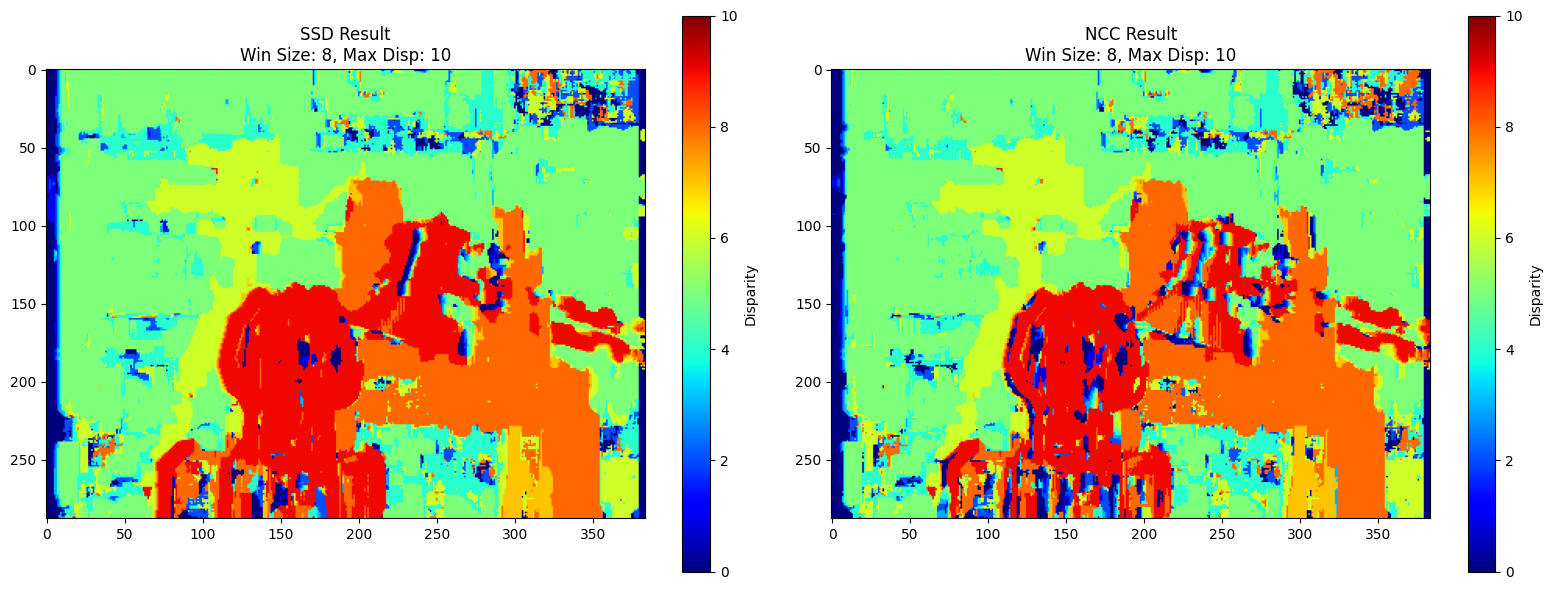

--- Processing: Window Size: 8, Max Disparity: 14 ---


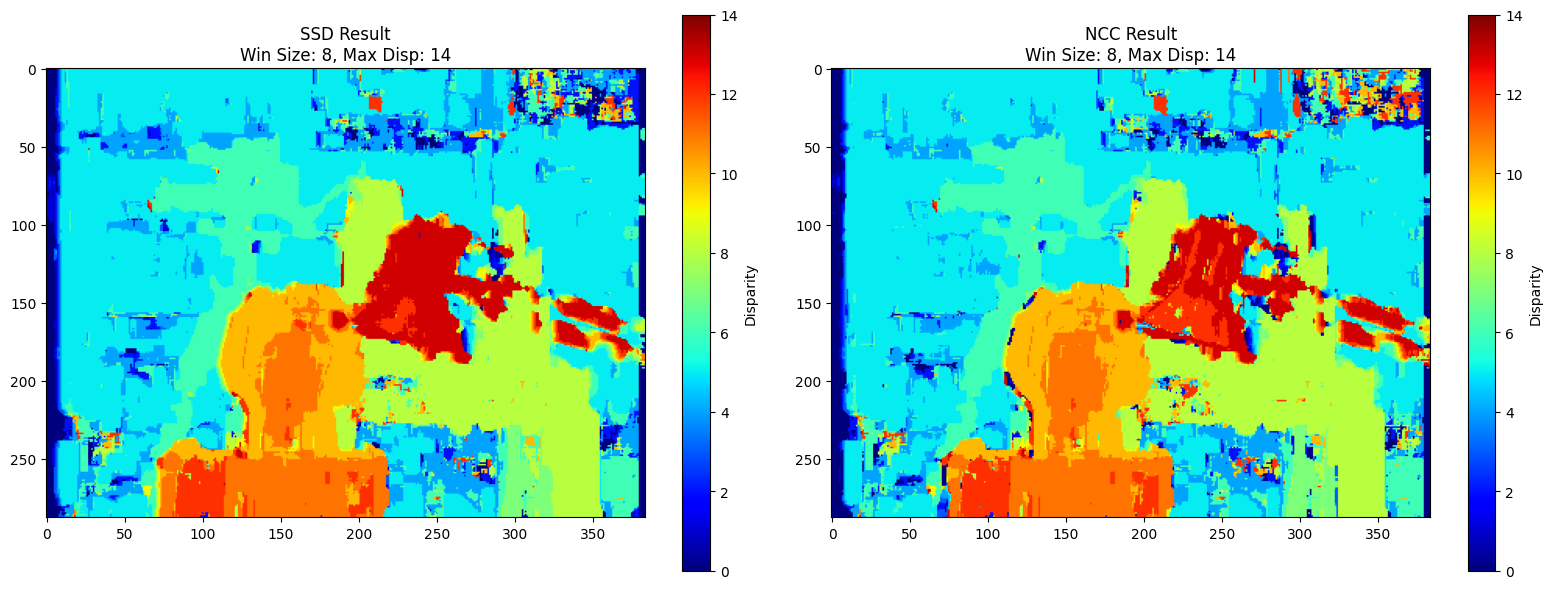

--- Processing: Window Size: 8, Max Disparity: 32 ---


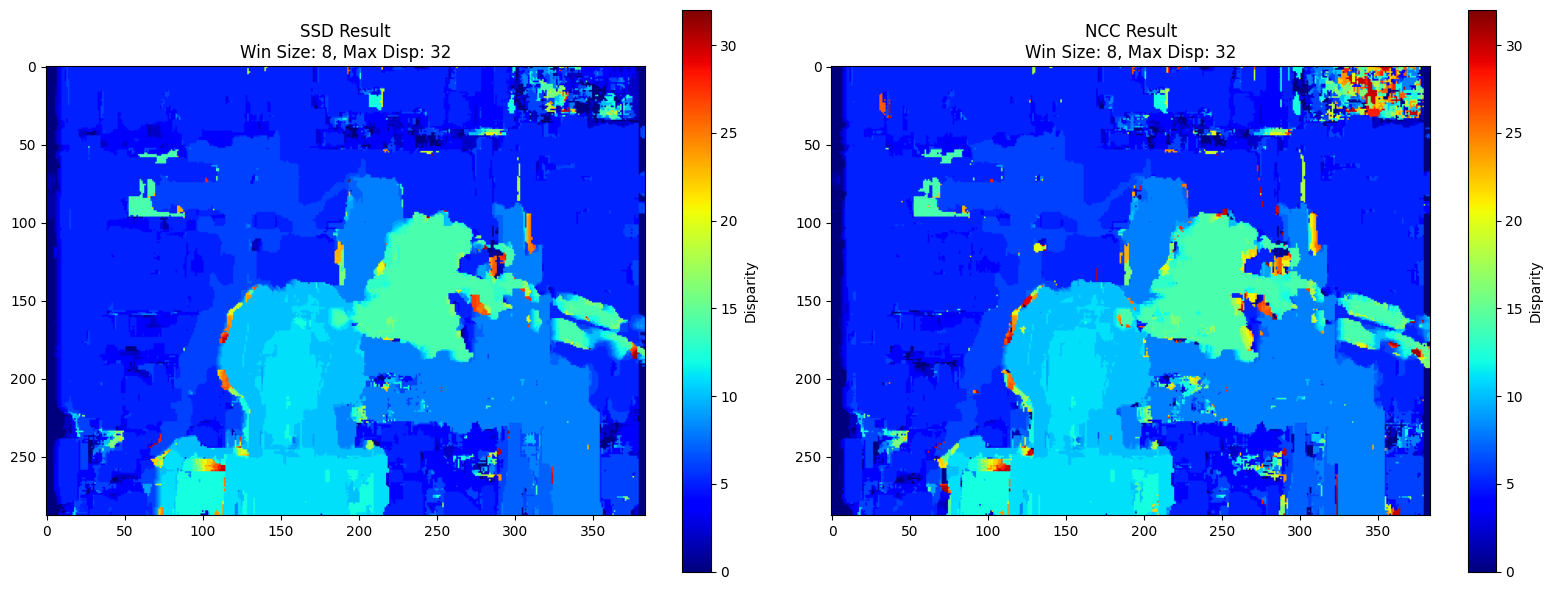

--- Processing: Window Size: 15, Max Disparity: 10 ---


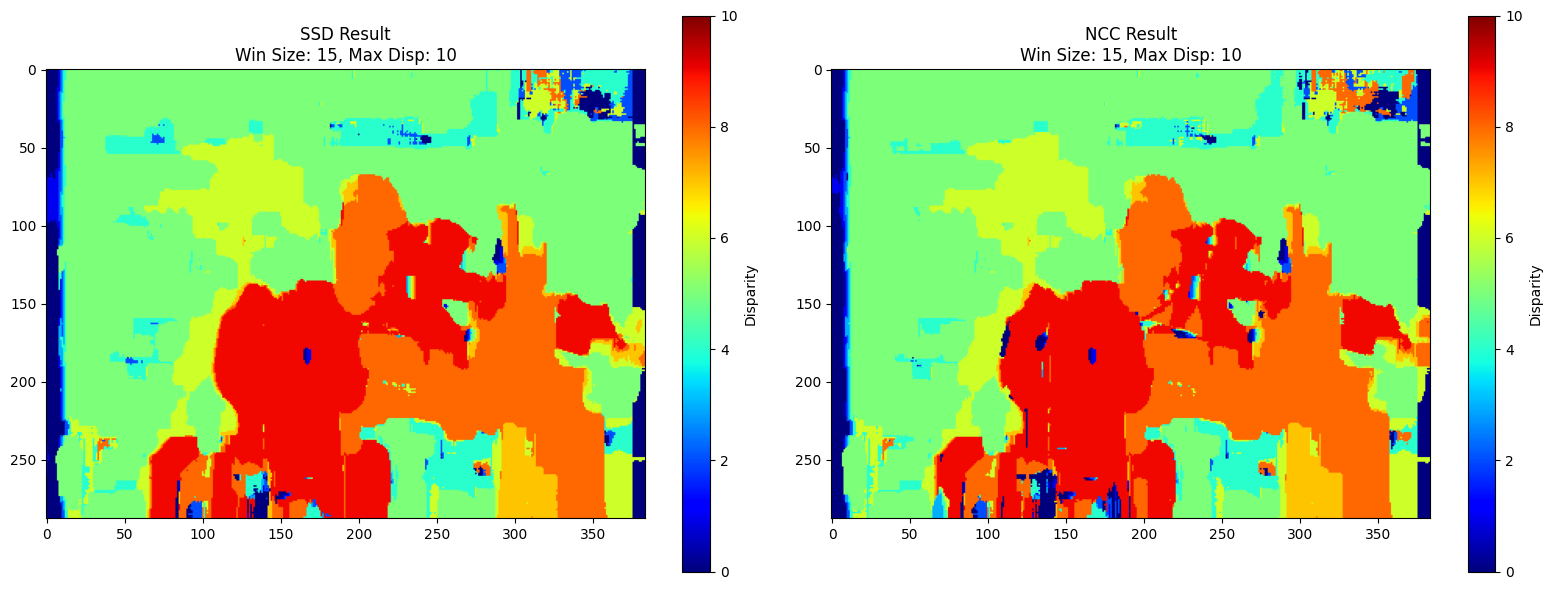

--- Processing: Window Size: 15, Max Disparity: 14 ---


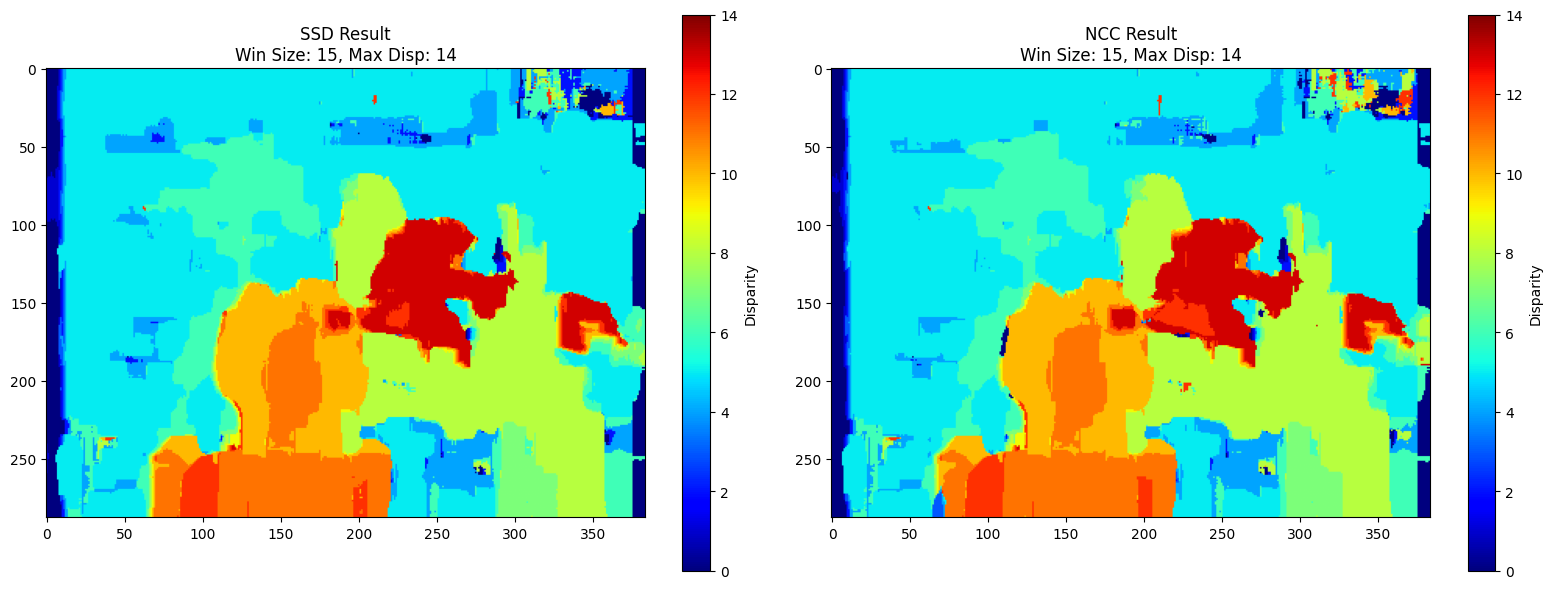

--- Processing: Window Size: 15, Max Disparity: 32 ---


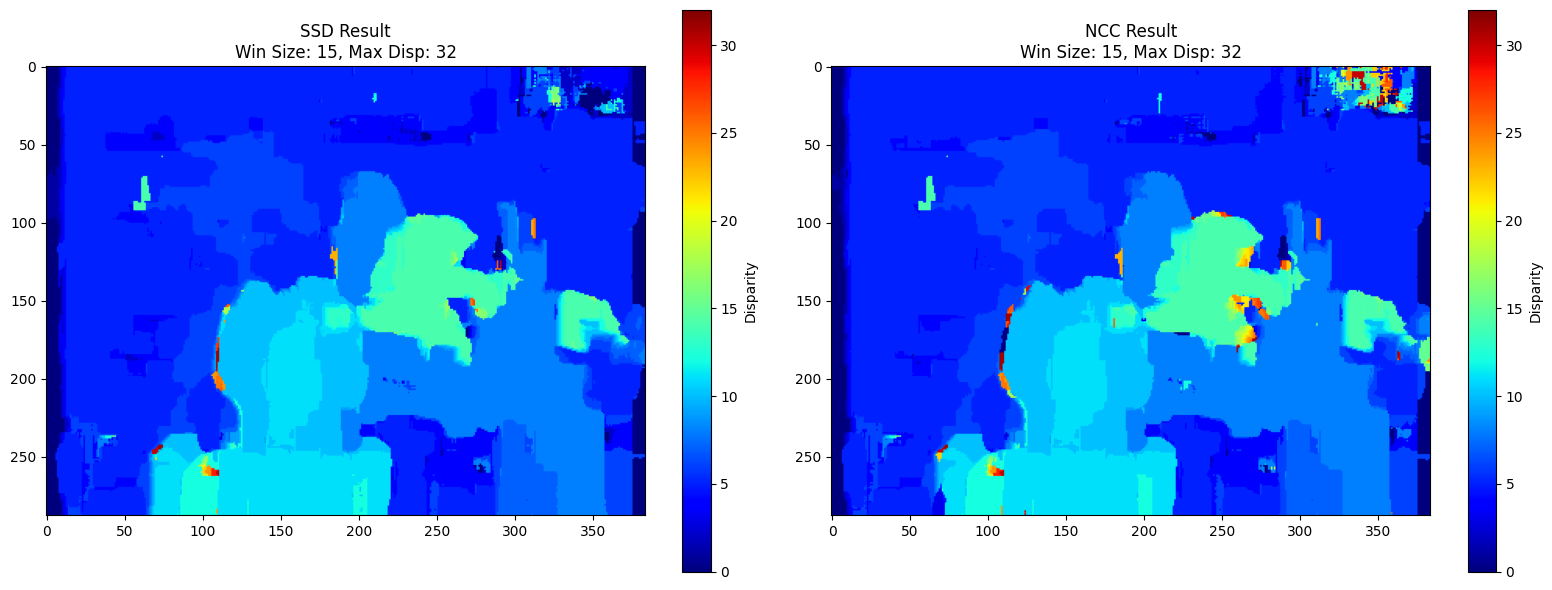

--- Processing: Window Size: 9, Max Disparity: 10 ---


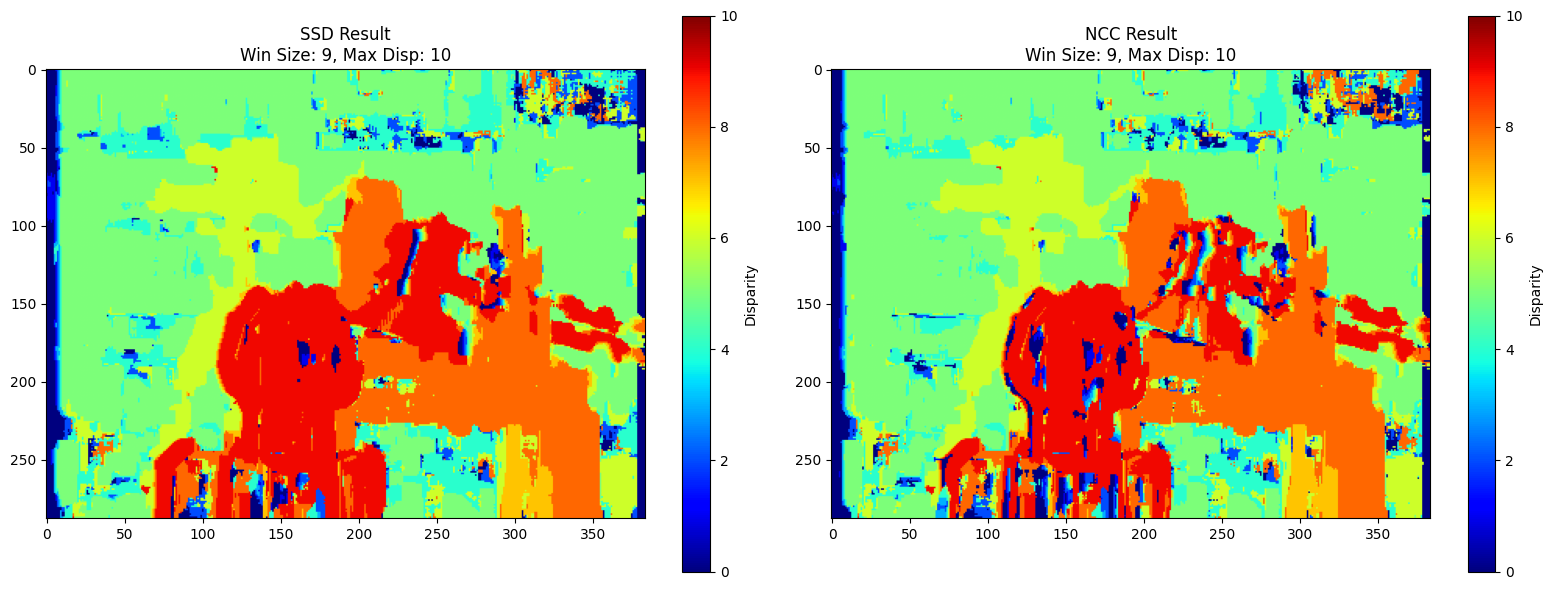

--- Processing: Window Size: 9, Max Disparity: 14 ---


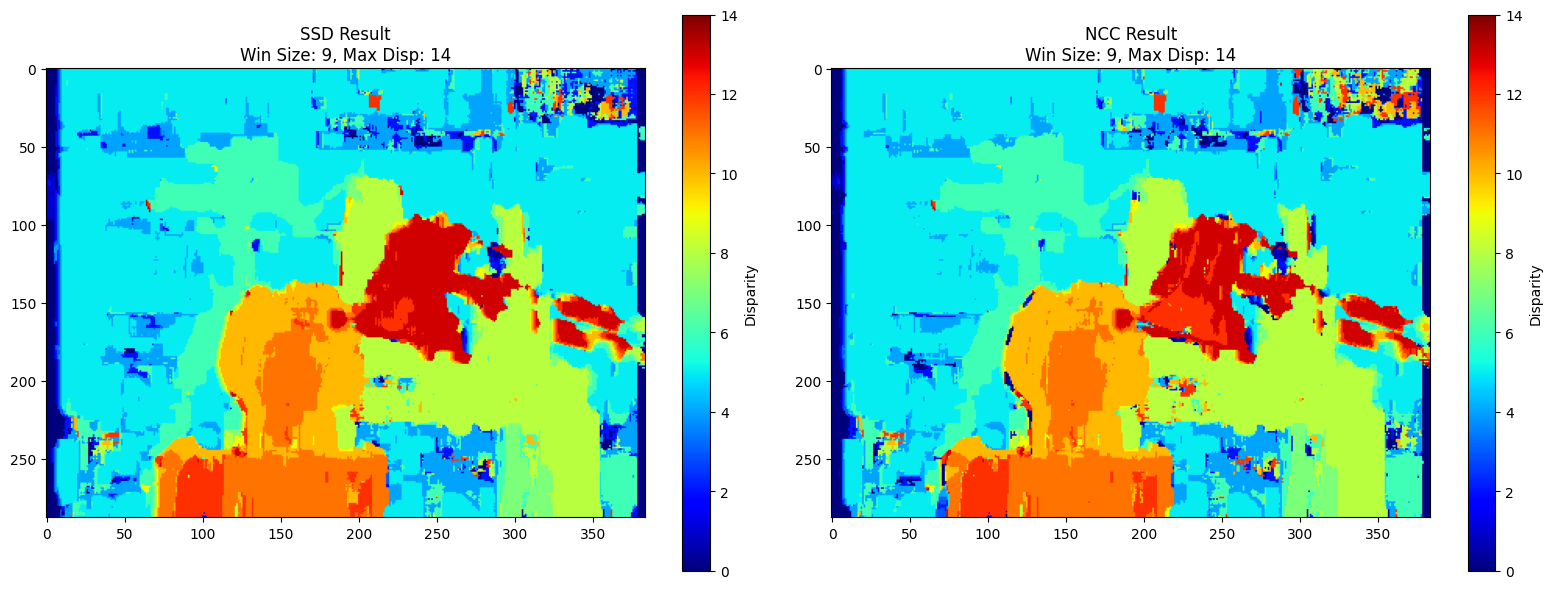

--- Processing: Window Size: 9, Max Disparity: 32 ---


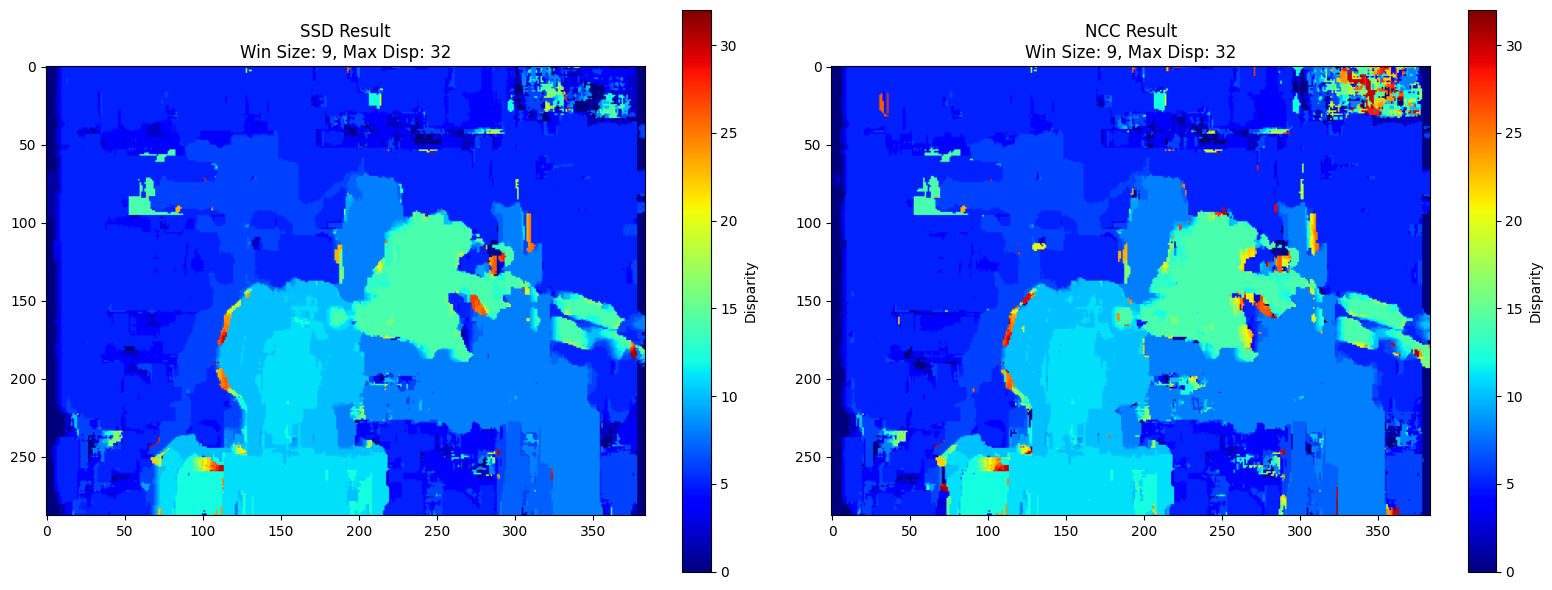

In [8]:
# Load images
try:
    left = cv2.cvtColor(cv2.imread('data/exercise_5/left.jpg'), cv2.COLOR_BGR2GRAY).astype('float32') / 255.
    right = cv2.cvtColor(cv2.imread('data/exercise_5/right.jpg'), cv2.COLOR_BGR2GRAY).astype('float32') / 255.
except cv2.error:
    print("Error: Could not load images. Ensure the path 'data/exercise_5/' is correct.")
    # Create dummy images to allow the script to run
    left = np.zeros((100, 100))
    right = np.zeros((100, 100))

# Parameters to experiment with
win_sizes_ = [8,15,9]
max_disps_ = [10,14,32]

for win_size in win_sizes_:
    for max_disp in max_disps_:
        print(f"--- Processing: Window Size: {win_size}, Max Disparity: {max_disp} ---")

        disparity_map_ssd = stereo_corr_ssd(left, right, win_size, max_disp)
        disparity_map_NCC = stereo_corr_NCC(left, right, win_size, max_disp)

        # --- Plotting Results ---
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # Plot SSD
        im_ssd = axes[0].imshow(disparity_map_ssd, cmap='jet', vmin=0, vmax=max_disp)
        axes[0].set_title(f'SSD Result\nWin Size: {win_size}, Max Disp: {max_disp}')
        fig.colorbar(im_ssd, ax=axes[0], orientation='vertical', label='Disparity')

        # Plot NCC
        im_ncc = axes[1].imshow(disparity_map_NCC, cmap='jet', vmin=0, vmax=max_disp)
        axes[1].set_title(f'NCC Result\nWin Size: {win_size}, Max Disp: {max_disp}')
        fig.colorbar(im_ncc, ax=axes[1], orientation='vertical', label='Disparity')

        plt.tight_layout()
        plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')